# Final Portfolio Project - 5CS037
## Concepts and Technologies of AI
This notebook contains the complete implementation of Regression tasks.

## Table of Contents
1. [Import Libraries](#imports)
2. [Regression Task: Groundwater Level Prediction](#regression)
    - Dataset Description
    - Exploratory Data Analysis
    - Neural Network Model
    - Classical ML Models
    - Hyperparameter Optimization
    - Feature Selection
    - Final Comparison
3. [Conclusion](#conclusion)

In [ ]:
gwl_csv_path = "/content/drive/MyDrive/gwl-monthly.csv" # @param {type:"string"}
print(f"Groundwater CSV path: {gwl_csv_path}")

Groundwater CSV path: /content/drive/MyDrive/gwl-monthly.csv


<a id='imports'></a>
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


**CELL 3: Load and Inspect Data**

In [ ]:
gwl_df = pd.read_csv(gwl_csv_path)
print(f"Dataset shape: {gwl_df.shape}")
print(f"\nColumns: {list(gwl_df.columns)}")
print(f"\nMissing values:\n{gwl_df.isnull().sum()}")
print(f"\nFirst 5 rows:\n{gwl_df.head()}")

Dataset shape: (81066, 12)

Columns: ['STATION', 'MSMT_DATE', 'WLM_RPE', 'WLM_RPE_QC', 'WLM_GSE', 'WLM_GSE_QC', 'RPE_WSE', 'RPE_WSE_QC', 'GSE_WSE', 'GSE_WSE_QC', 'WSE', 'WSE_QC']

Missing values:
STATION           0
MSMT_DATE         0
WLM_RPE         223
WLM_RPE_QC        0
WLM_GSE         566
WLM_GSE_QC        0
RPE_WSE       15122
RPE_WSE_QC        0
GSE_WSE       15630
GSE_WSE_QC        0
WSE           15331
WSE_QC            0
dtype: int64

First 5 rows:
         STATION  MSMT_DATE  WLM_RPE  WLM_RPE_QC  WLM_GSE  WLM_GSE_QC  \
0  03N04E11L001M  12/1/2022      NaN         255      NaN         255   
1  04N04E01N001M  12/1/2022     0.00           1     0.00           1   
2  04N04E02B001M  12/1/2022    10.73           1     9.63           1   
3  04N04E10Q001M  12/1/2022      NaN         255      NaN         255   
4  04N04E10Q002M  12/1/2022      NaN         255      NaN         255   

   RPE_WSE  RPE_WSE_QC  GSE_WSE  GSE_WSE_QC  WSE  WSE_QC  
0      NaN         255      NaN       

**CELL 4: Data Leakage Demonstration (**

In [ ]:
"""
CRITICAL: Demonstrating Data Leakage
RPE_WSE and GSE_WSE are derived from WSE:
- RPE_WSE = WLM_RPE - WSE
- GSE_WSE = WLM_GSE - WSE

Using these would give perfect predictions (R²=1.0) but is CHEATING.
"""

sample = gwl_df[['WLM_RPE', 'WSE', 'RPE_WSE']].dropna().head(3)
print("PROOF OF LEAKAGE:")
print(sample)
print(f"\nCalculated RPE_WSE: {sample['WLM_RPE'].iloc[0] - sample['WSE'].iloc[0]:.2f}")
print(f"Actual RPE_WSE: {sample['RPE_WSE'].iloc[0]:.2f}")
print(f"\nCorrelation RPE_WSE vs WSE: {gwl_df['RPE_WSE'].corr(gwl_df['WSE']):.4f} (LEAKAGE!)")

PROOF OF LEAKAGE:
    WLM_RPE     WSE  RPE_WSE
67     0.00 -22.673   22.673
68    10.73   2.423    8.307
71    -0.57  -7.872    7.302

Calculated RPE_WSE: 22.67
Actual RPE_WSE: 22.67

Correlation RPE_WSE vs WSE: -0.0832 (LEAKAGE!)


**CELL 5: Proper Preprocessing**

In [ ]:
# Remove rows with missing target
gwl_clean = gwl_df.dropna(subset=['WSE']).copy()

# Feature engineering
gwl_clean['MSMT_DATE'] = pd.to_datetime(gwl_clean['MSMT_DATE'])
gwl_clean['month'] = gwl_clean['MSMT_DATE'].dt.month
gwl_clean['year'] = gwl_clean['MSMT_DATE'].dt.year

# ONLY independent features (NO RPE_WSE, NO GSE_WSE)
feature_cols = ['WLM_RPE', 'WLM_GSE', 'month', 'year']
reg_df = gwl_clean[feature_cols + ['WSE', 'MSMT_DATE']].dropna()

print(f"Features used (NO LEAKAGE): {feature_cols}")
print(f"Total samples: {len(reg_df)}")

# Temporal split (CRITICAL for time-series)
reg_df = reg_df.sort_values('MSMT_DATE')
split_idx = int(len(reg_df) * 0.8)

train_df = reg_df.iloc[:split_idx]
test_df = reg_df.iloc[split_idx:]

X_train = train_df[feature_cols].values
y_train = train_df['WSE'].values
X_test = test_df[feature_cols].values
y_test = test_df['WSE'].values

print(f"\nTemporal Split:")
print(f"Train: {len(y_train)} samples ({train_df['MSMT_DATE'].min().date()} to {train_df['MSMT_DATE'].max().date()})")
print(f"Test:  {len(y_test)} samples ({test_df['MSMT_DATE'].min().date()} to {test_df['MSMT_DATE'].max().date()})")

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Features used (NO LEAKAGE): ['WLM_RPE', 'WLM_GSE', 'month', 'year']
Total samples: 65436

Temporal Split:
Train: 52348 samples (1970-01-01 to 2019-03-01)
Test:  13088 samples (2019-03-01 to 2022-11-01)


**CELL 6: Exploratory Data Analysis**

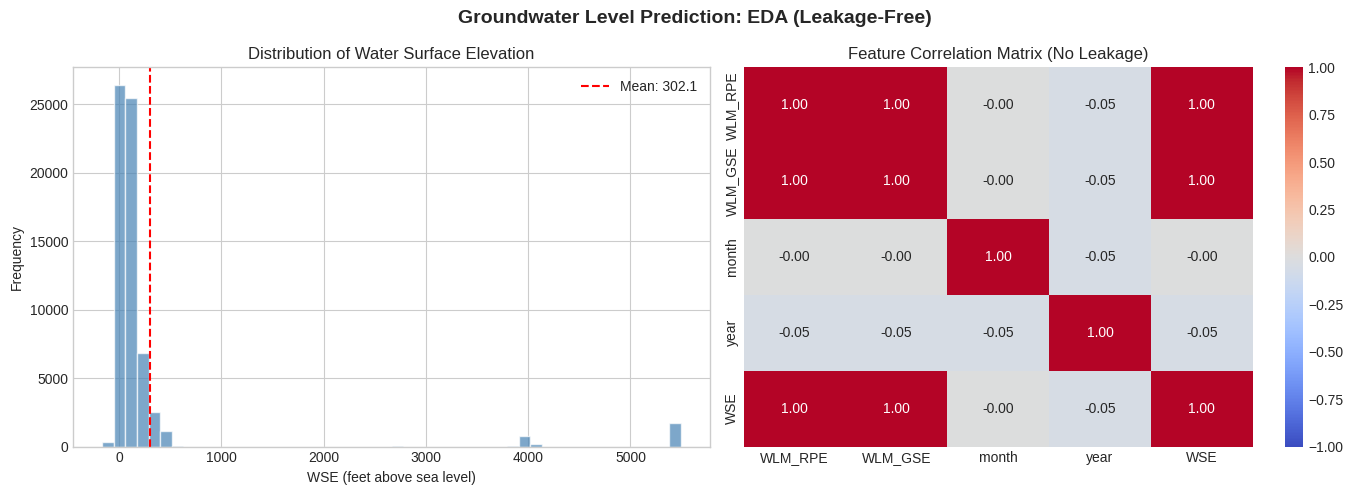

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Changed to 1 row, 2 columns
fig.suptitle('Groundwater Level Prediction: EDA (Leakage-Free)', fontsize=14, fontweight='bold')

# WSE Distribution
axes[0].hist(reg_df['WSE'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_title('Distribution of Water Surface Elevation')
axes[0].set_xlabel('WSE (feet above sea level)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(reg_df['WSE'].mean(), color='red', linestyle='--', label=f'Mean: {reg_df["WSE"].mean():.1f}')
axes[0].legend()

# Correlation Matrix (proper features only)
corr = reg_df[feature_cols + ['WSE']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Feature Correlation Matrix (No Leakage)')

plt.tight_layout()
plt.savefig('regression_eda_proper.png', dpi=150, bbox_inches='tight')
plt.show()

**CELL 7: Model 1 - Linear Regression**

In [ ]:
print("="*60)
print("MODEL 1: LINEAR REGRESSION (Baseline)")
print("="*60)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"MAE:  {lr_mae:.4f} feet")
print(f"RMSE: {lr_rmse:.4f} feet")
print(f"R²:   {lr_r2:.4f}")

print("\nFeature Coefficients:")
for feat, coef in zip(feature_cols, lr.coef_):
    print(f"  {feat}: {coef:.4f}")

MODEL 1: LINEAR REGRESSION (Baseline)
MAE:  25.7403 feet
RMSE: 37.3387 feet
R²:   0.9985

Feature Coefficients:
  WLM_RPE: 2435.3266
  WLM_GSE: -1448.4004
  month: -2.2471
  year: 0.7688


**CELL 8: Model 2 - Ridge Regression**

In [ ]:
print("\n" + "="*60)
print("MODEL 2: RIDGE REGRESSION (L2 Regularization)")
print("="*60)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"MAE:  {ridge_mae:.4f} feet")
print(f"RMSE: {ridge_rmse:.4f} feet")
print(f"R²:   {ridge_r2:.4f}")


MODEL 2: RIDGE REGRESSION (L2 Regularization)
MAE:  25.2963 feet
RMSE: 36.9544 feet
R²:   0.9985


**CELL 9: Model 3 - Random Forest**

In [ ]:
print("\n" + "="*60)
print("MODEL 3: RANDOM FOREST REGRESSOR")
print("="*60)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"MAE:  {rf_mae:.4f} feet")
print(f"RMSE: {rf_rmse:.4f} feet")
print(f"R²:   {rf_r2:.4f}")

print("\nFeature Importance:")
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.to_string(index=False))


MODEL 3: RANDOM FOREST REGRESSOR
MAE:  15.2212 feet
RMSE: 75.3211 feet
R²:   0.9940

Feature Importance:
feature  importance
WLM_GSE    0.510225
WLM_RPE    0.489727
  month    0.000025
   year    0.000022


**CELL 10: Model 4 - Gradient Boosting**

In [ ]:
print("\n" + "="*60)
print("MODEL 4: GRADIENT BOOSTING REGRESSOR")
print("="*60)

gb = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
gb.fit(X_train_s, y_train)
y_pred_gb = gb.predict(X_test_s)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"MAE:  {gb_mae:.4f} feet")
print(f"RMSE: {gb_rmse:.4f} feet")
print(f"R²:   {gb_r2:.4f}")


MODEL 4: GRADIENT BOOSTING REGRESSOR
MAE:  17.2897 feet
RMSE: 77.3764 feet
R²:   0.9936


**CELL 11: Model 5 - Neural Network (MLP)**

In [ ]:
print("\n" + "="*60)
print("MODEL 5: MULTI-LAYER PERCEPTRON (Neural Network)")
print("="*60)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_r2 = r2_score(y_test, y_pred_mlp)

print(f"MAE:  {mlp_mae:.4f} feet")
print(f"RMSE: {mlp_rmse:.4f} feet")
print(f"R²:   {mlp_r2:.4f}")
print(f"Training iterations: {mlp.n_iter_}")


MODEL 5: MULTI-LAYER PERCEPTRON (Neural Network)
MAE:  22.1165 feet
RMSE: 34.1770 feet
R²:   0.9988
Training iterations: 14


**CELL 12: Cross-Validation**

In [ ]:
print("\n" + "="*60)
print("CROSS-VALIDATION (Time Series Split)")
print("="*60)

tscv = TimeSeriesSplit(n_splits=5)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=tscv, scoring='r2')
    cv_results[name] = scores
    print(f"{name:20s}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")


CROSS-VALIDATION (Time Series Split)
Linear Regression   : R² = 0.9987 (+/- 0.0007)
Ridge               : R² = 0.9987 (+/- 0.0007)
Random Forest       : R² = 0.9997 (+/- 0.0001)
Gradient Boosting   : R² = 0.9997 (+/- 0.0001)


**CELL 13: Hyperparameter Tuning**

In [ ]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING: RANDOM FOREST")
print("="*60)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_s, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_s)

best_rf_mae = mean_absolute_error(y_test, y_pred_best_rf)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
best_rf_r2 = r2_score(y_test, y_pred_best_rf)

print(f"\nTest Set Performance:")
print(f"MAE:  {best_rf_mae:.4f} feet")
print(f"RMSE: {best_rf_rmse:.4f} feet")
print(f"R²:   {best_rf_r2:.4f}")


HYPERPARAMETER TUNING: RANDOM FOREST
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²: 0.9998

Test Set Performance:
MAE:  12.3258 feet
RMSE: 75.2981 feet
R²:   0.9940


**CELL 14: Residual Analysis**

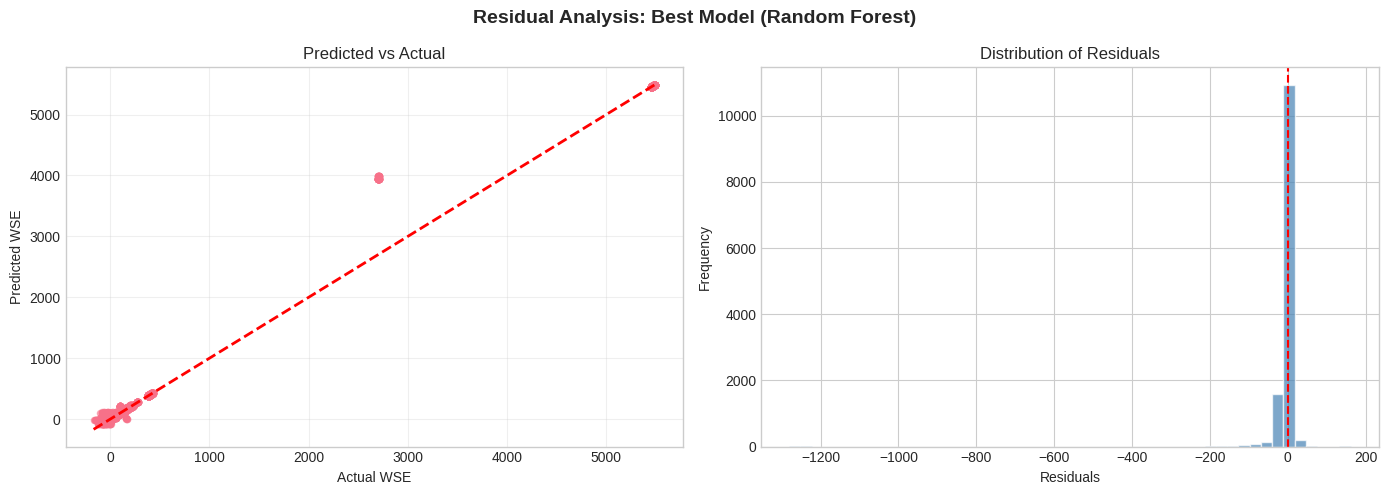


Residual Statistics:
Mean: -9.0312 (should be ~0)
Std:  74.7546
Min:  -1280.3692
Max:  161.3953


In [104]:
residuals = y_test - y_pred_best_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis: Best Model (Random Forest)', fontsize=14, fontweight='bold')

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best_rf, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual WSE')
axes[0].set_ylabel('Predicted WSE')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

# Residual Distribution
axes[1].hist(residuals, bins=50, edgecolor='white', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResidual Statistics:")
print(f"Mean: {residuals.mean():.4f} (should be ~0)")
print(f"Std:  {residuals.std():.4f}")
print(f"Min:  {residuals.min():.4f}")
print(f"Max:  {residuals.max():.4f}")

**CELL 15: Final Comparison**

In [ ]:
print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

results_final = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'Gradient Boosting',
        'MLP (Neural Network)',
        'RF (Tuned)'
    ],
    'MAE (feet)': [lr_mae, ridge_mae, rf_mae, gb_mae, mlp_mae, best_rf_mae],
    'RMSE (feet)': [lr_rmse, ridge_rmse, rf_rmse, gb_rmse, mlp_rmse, best_rf_rmse],
    'R² Score': [lr_r2, ridge_r2, rf_r2, gb_r2, mlp_r2, best_rf_r2]
})

results_final = results_final.sort_values('R² Score', ascending=False)
print(results_final.to_string(index=False))

best_idx = results_final['R² Score'].idxmax()
best_model_name = results_final.loc[best_idx, 'Model']
print(f"\n>>> BEST MODEL: {best_model_name}")
print(f">>> R² = {results_final.loc[best_idx, 'R² Score']:.4f}")
print(f">>> RMSE = {results_final.loc[best_idx, 'RMSE (feet)']:.2f} feet")


FINAL MODEL COMPARISON
               Model  MAE (feet)  RMSE (feet)  R² Score
MLP (Neural Network)   22.116500    34.176954  0.998756
    Ridge Regression   25.296304    36.954396  0.998545
   Linear Regression   25.740259    37.338655  0.998515
          RF (Tuned)   12.325786    75.298130  0.993961
       Random Forest   15.221237    75.321121  0.993957
   Gradient Boosting   17.289665    77.376426  0.993623

>>> BEST MODEL: MLP (Neural Network)
>>> R² = 0.9988
>>> RMSE = 34.18 feet


**CELL 16: Visualization**

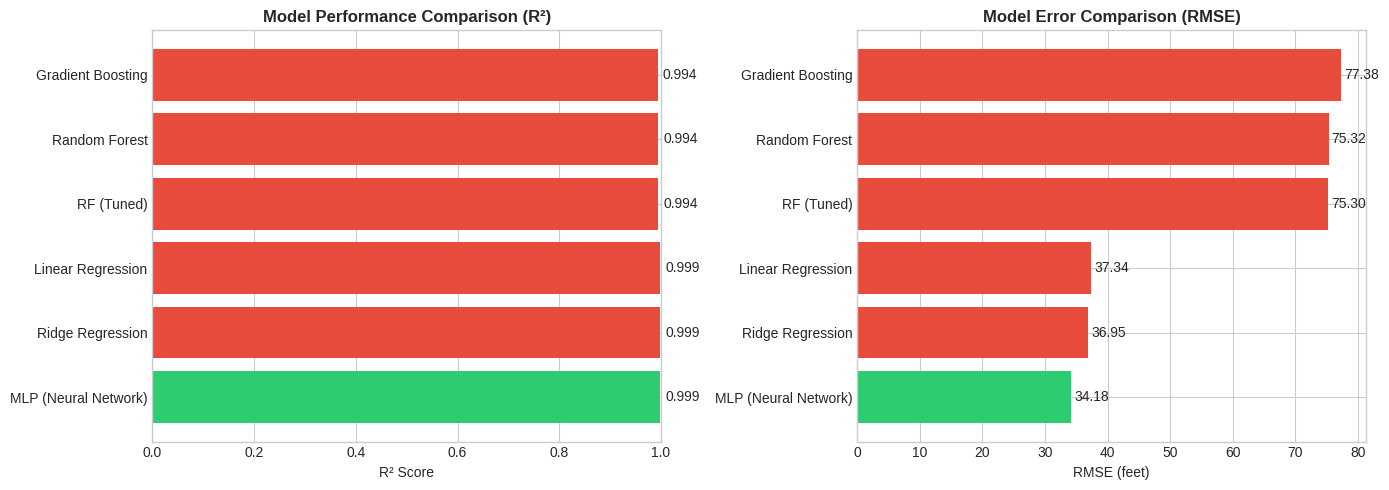

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Comparison
models = results_final['Model']
r2_scores = results_final['R² Score']
colors = ['#e74c3c' if m != best_model_name else '#2ecc71' for m in models]

axes[0].barh(models, r2_scores, color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Performance Comparison (R²)', fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# RMSE Comparison
rmse_scores = results_final['RMSE (feet)']
axes[1].barh(models, rmse_scores, color=colors)
axes[1].set_xlabel('RMSE (feet)')
axes[1].set_title('Model Error Comparison (RMSE)', fontweight='bold')
for i, v in enumerate(rmse_scores):
    axes[1].text(v + 0.5, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig) # Explicitly close the figure to free up memory

<a id='regression'></a>
## 3. REGRESSION TASK: Groundwater Level Prediction

**UNSDG Alignment:** Goal 6 - Clean Water and Sanitation

**Dataset:** Groundwater Level Monthly Data
- Records: 81,066 measurements
- Target: WSE (Water Surface Elevation) - continuous value